<a href="https://colab.research.google.com/github/aydaysharabidinova/data-science/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
try:
  df_oscars = pd.read_excel("oscars.xlsx")
  print(df_oscars.head())
except:
  df_oscars = pd.read_csv('oscars.csv')

   year_film  year_ceremony  ceremony      Category  gender           name  \
0       1927           1928         1    Best Actor    Male  Emil Jannings   
1       1927           1928         1  Best Actress  Female   Janet Gaynor   
2       1928           1929         2    Best Actor    Male  Warner Baxter   
3       1928           1929         2  Best Actress  Female  Mary Pickford   
4       1929           1930         3    Best Actor    Male  George Arliss   

    Race              film  winner  
0  White  The Last Command    True  
1  White        7th Heaven    True  
2  White    In Old Arizona    True  
3  White          Coquette    True  
4  White          Disraeli    True  


In [ ]:
#Step 3-4 Constructing pie chart

In [ ]:
# Clean gender column
df_oscars['gender'] = (
    df_oscars['gender']
    .astype(str)
    .str.strip()
    .str.lower()
)
df_oscars = df_oscars[df_oscars['gender'].isin(['male', 'female'])]

gender
male      8270
female    2126
Name: count, dtype: int64
Plot saved as 'oscars.png'


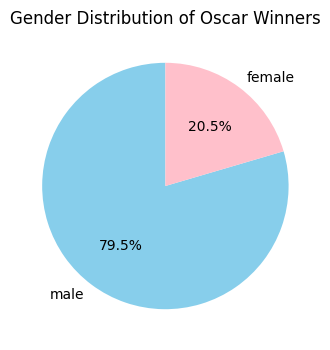

In [ ]:
gender_counts = df_oscars['gender'].dropna().value_counts()
print(gender_counts)
plt.figure(figsize=(4,4))
gender_counts.plot(kind='pie',
                   autopct='%1.1f%%',
                   startangle=90,
                   colors=['skyblue', 'pink']
                   )
plt.title('Gender Distribution of Oscar Winners')
plt.savefig('oscars.png', dpi=300, bbox_inches='tight')
plt.ylabel('')
print("Plot saved as 'oscars.png'")
try:
    plt.show()
except Exception as e:
    print(f"Display error: {e}")
    print("The plot has been saved as 'oscars.png' in the current directory.")

remain 7 categories, improve

In [ ]:
#5-6 Bar chart of the winners across categories

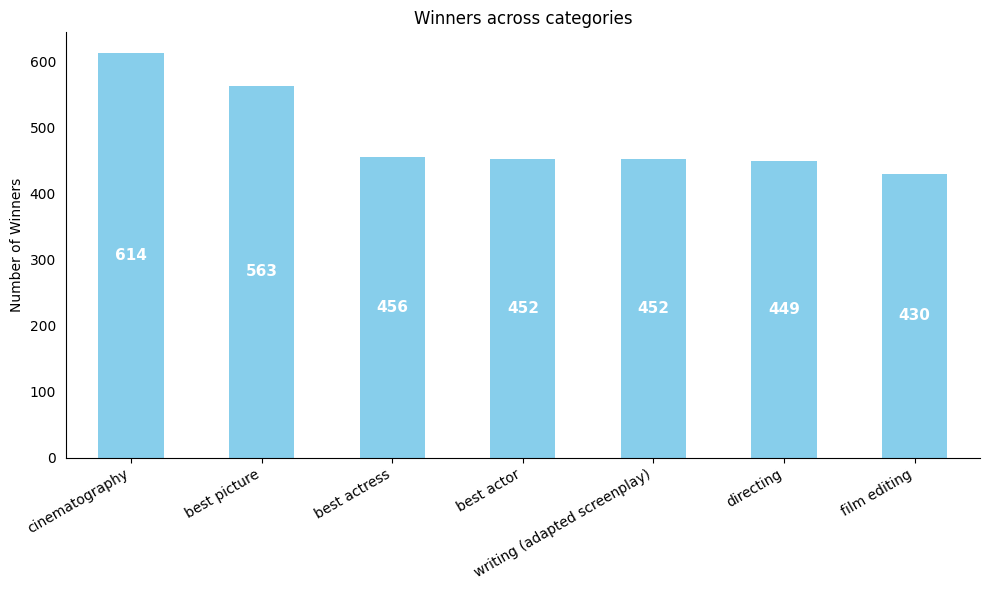

In [ ]:
top7 = df_oscars['Category'].value_counts().head(7)
plt.figure(figsize=(10,6))

ax = top7.plot(kind='bar', color='skyblue')

# Titles and labels in lowercase

plt.title('Winners across categories')
plt.ylabel('Number of Winners')
plt.xlabel('')

# Convert x-axis labels to lowercase

ax.set_xticklabels([label.get_text().lower() for label in ax.get_xticklabels()], rotation=30, ha='right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Add number on top of each bar

for bar, value in zip(ax.patches, top7.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value / 2,              # inside the bar
        f'{value}',
        ha='center',
        va='center',
        fontsize=11,
        color='white',
        fontweight='bold'
    )

ax.tick_params(left=False)
plt.tight_layout()
plt.savefig('bar_winners.png', dpi = 300)
plt.show()

In [ ]:
#Step 7 Number of winners for the N most frequent categories

How many most frequent categories you want? 
7


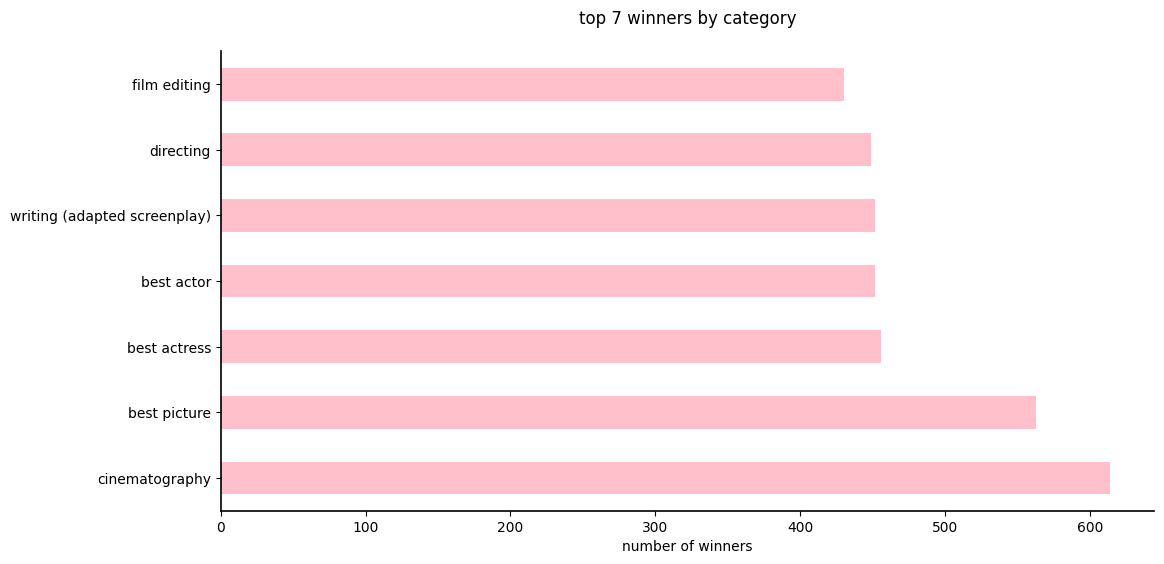

In [ ]:
import matplotlib.pyplot as plt

print('How many most frequent categories you want? ')
n_most_frequent = int(input())

plt.close()

top_winners = df_oscars['Category'].value_counts().head(n_most_frequent)

plt.figure(figsize=(12, 6))
ax2 = top_winners.plot(kind='barh', color='pink')

plt.title(f'top {n_most_frequent} winners by category', pad=20)
plt.xlabel('number of winners')
plt.ylabel('')

# Convert y-axis labels to lowercase
ax2.set_yticklabels(
    [label.get_text().lower() for label in ax2.get_yticklabels()]
)

# Remove frame but keep axes
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(True)
ax2.spines['bottom'].set_visible(True)

ax2.spines['left'].set_linewidth(1.2)
ax2.spines['bottom'].set_linewidth(1.2)

ax2.tick_params(left=True, bottom=True)

plt.tight_layout(pad=2)
plt.savefig('top_n_winners_by_category.png', dpi=300)
plt.show()